# Линейная регрессия и SGD

Спрогнозируем продажи по рекламным расходам и сравним аналитическую линейную регрессию со стохастическим градиентным спуском.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Данные

,TV,Radio,Newspaper,Sales
0,12.703834,18.763907,117.048519,5.186440
1,133.481328,48.496594,55.317699,18.848105
2,164.096336,8.646365,77.103107,15.834817
3,44.022970,15.983278,110.239754,10.725402
4,100.885749,14.698024,29.840959,7.111533


,count,mean,std,min,25%,50%,75%,max
TV,500.0,146.617105,87.086626,1.457201,73.653765,146.402058,224.205268,299.929601
Radio,500.0,25.019550,14.420587,0.049500,12.241616,25.222581,37.349811,49.969502
Newspaper,500.0,59.275001,35.372874,0.077076,29.283047,60.716395,89.024089,119.929071
Sales,500.0,14.420952,5.172234,2.494658,10.723214,14.031589,17.994561,27.541602


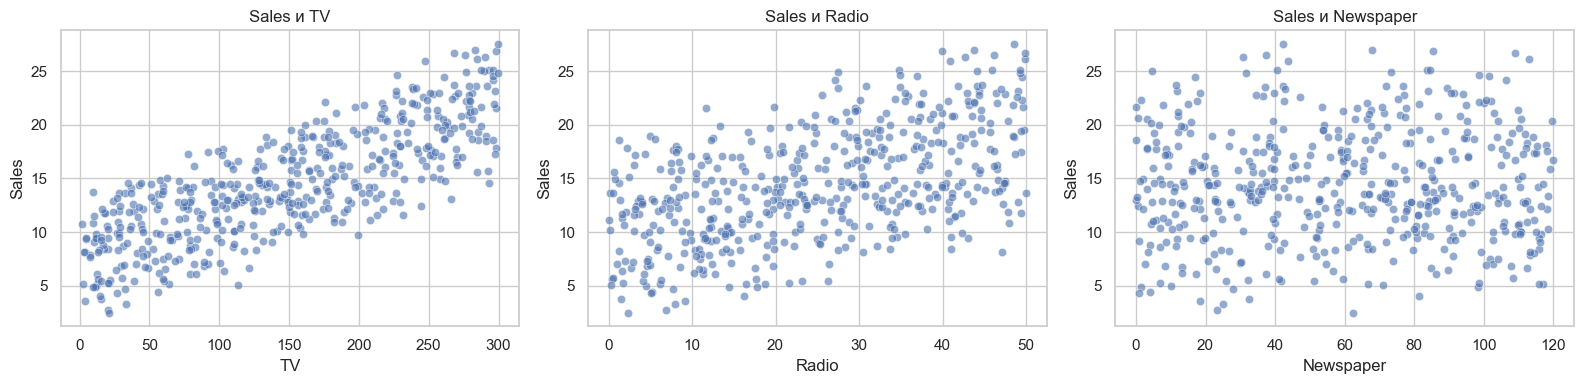

In [2]:
data = pd.read_csv("advertising.csv")
display(data.head())
display(data.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for column, axis in zip(["TV", "Radio", "Newspaper"], axes):
    sns.scatterplot(data=data, x=column, y="Sales", ax=axis, alpha=0.6)
    axis.set_title(f"Sales и {column}")
plt.tight_layout()
plt.show()

## Обучение и сравнение

In [3]:
features = data.drop(columns="Sales")
target = data["Sales"]
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42
)

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "SGD Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDRegressor(max_iter=5000, tol=1e-5, penalty="l2", alpha=0.001, random_state=42)),
    ]),
}

rows = []
predictions = {}
for name, model in models.items():
    model.fit(train_features, train_target)
    prediction = model.predict(test_features)
    predictions[name] = prediction
    rows.append({
        "model": name,
        "MAE": mean_absolute_error(test_target, prediction),
        "RMSE": root_mean_squared_error(test_target, prediction),
        "R2": model.score(test_features, test_target),
    })

results = pd.DataFrame(rows).set_index("model")
results

,MAE,RMSE,R2
model,,,
Linear Regression,1.455122,1.788577,0.854799
SGD Regressor,1.453894,1.787581,0.854961


## Факт и прогноз

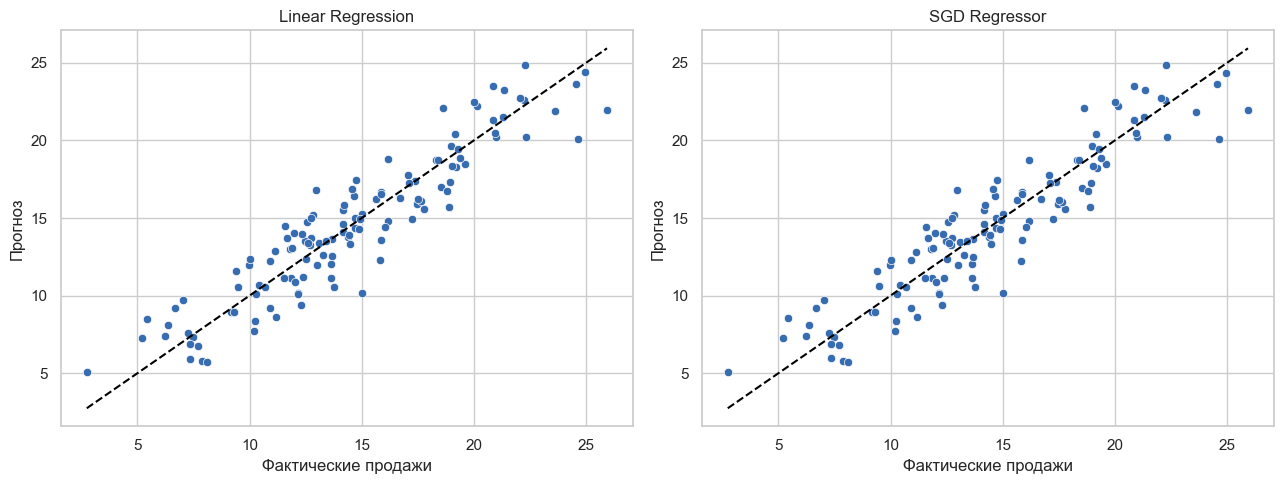

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
limits = [test_target.min(), test_target.max()]
for axis, (name, prediction) in zip(axes, predictions.items()):
    sns.scatterplot(x=test_target, y=prediction, ax=axis, color="#386cb0")
    axis.plot(limits, limits, linestyle="--", color="black")
    axis.set_title(name)
    axis.set_xlabel("Фактические продажи")
    axis.set_ylabel("Прогноз")
plt.tight_layout()
plt.show()

## Коэффициенты

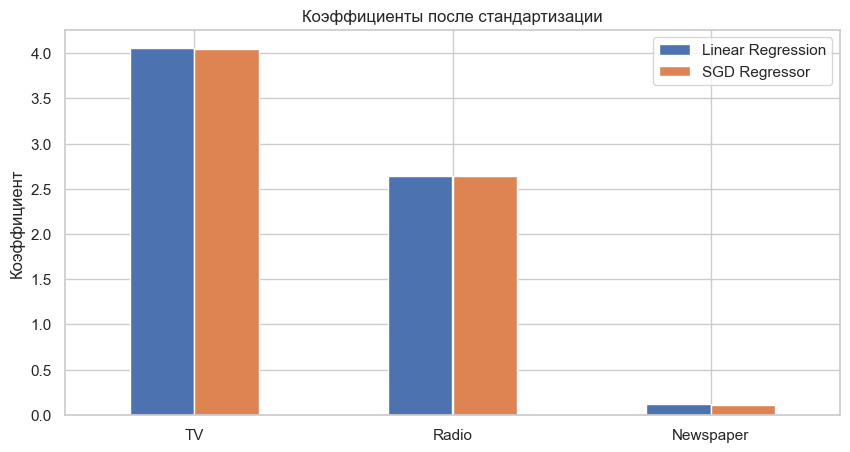

In [5]:
coefficient_frame = pd.DataFrame({
    name: model.named_steps["model"].coef_
    for name, model in models.items()
}, index=features.columns)

coefficient_frame.plot.bar(figsize=(10, 5))
plt.title("Коэффициенты после стандартизации")
plt.ylabel("Коэффициент")
plt.xticks(rotation=0)
plt.show()

## Вывод

Обе модели решают одну задачу, но SGD обновляет параметры по отдельным объектам или мини-батчам. Масштабирование признаков критично для устойчивой сходимости градиентного метода.